In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [4]:


import os
test_results = pd.read_csv(os.path.join('data', 'test_results.csv'))
test_results.head()

user_table = pd.read_csv(os.path.join('data', 'user_table.csv'))
user_table.head()

,user_id,city,country,lat,long
0,510335,Peabody,USA,42.53,-70.97
1,89568,Reno,USA,39.54,-119.82
2,434134,Rialto,USA,34.11,-117.39
3,289769,Carson City,USA,39.15,-119.74
4,939586,Chicago,USA,41.84,-87.68


In [7]:
print(user_table.info())
print('\n')
print(test_results.info())

<class 'pandas.DataFrame'>
RangeIndex: 275616 entries, 0 to 275615
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  275616 non-null  int64  
 1   city     275616 non-null  str    
 2   country  275616 non-null  str    
 3   lat      275616 non-null  float64
 4   long     275616 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 10.5 MB
None


<class 'pandas.DataFrame'>
RangeIndex: 316800 entries, 0 to 316799
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           316800 non-null  int64
 1   timestamp         316800 non-null  str  
 2   source            316800 non-null  str  
 3   device            316800 non-null  str  
 4   operative_system  316800 non-null  str  
 5   test              316800 non-null  int64
 6   price             316800 non-null  int64
 7   converted         316800 non-null  int64
dty

In [9]:
print(user_table.describe())
print('\n')
print(test_results.describe())

             user_id            lat           long
count  275616.000000  275616.000000  275616.000000
mean   499245.801521      37.111680     -93.981772
std    288533.458944       5.209627      18.086486
min         3.000000      19.700000    -157.800000
25%    249544.500000      33.660000    -112.200000
50%    498861.000000      37.740000     -88.930000
75%    748856.500000      40.700000     -78.910000
max    999999.000000      61.180000      30.310000


              user_id           test          price      converted
count   316800.000000  316800.000000  316800.000000  316800.000000
mean    499281.341840       0.360079      46.205051       0.018333
std     288591.154044       0.480024       9.601487       0.134154
min          3.000000       0.000000      39.000000       0.000000
25%     249525.750000       0.000000      39.000000       0.000000
50%     499021.500000       0.000000      39.000000       0.000000
75%     749025.500000       1.000000      59.000000       0.000000
max

In [ ]:
#check if a user is missing in both tables
print(user_table['user_id'].isin(test_results['user_id']).value_counts())
print(test_results['user_id'].isin(user_table['user_id']).value_counts())



user_id
True    275616
Name: count, dtype: int64
user_id
True     275616
False     41184
Name: count, dtype: int64


np.int64(0)

In [16]:
#merge the tables
merged_data = pd.merge(test_results, user_table, on='user_id', how='inner')
merged_data[merged_data.duplicated()]

,user_id,timestamp,source,device,operative_system,test,price,converted,city,country,lat,long


In [25]:
print('No of prices in the merged data', merged_data['price'].nunique())
print('Total prices counts', merged_data['price'].value_counts())

No of prices in the merged data 2
Total prices counts price
39    176376
59     99240
Name: count, dtype: int64


In [27]:
test_results['test'].value_counts(normalize=True)

test
0    0.639921
1    0.360079
Name: proportion, dtype: float64

In [33]:
pd.crosstab(merged_data['test'], merged_data['price'])

price,39,59
test,,
0,176241,187
1,135,99053


In [37]:
for col in ['source', 'device', 'operative_system']:
    print(f"\n--- {col} ---")
    print(pd.crosstab(merged_data['test'], merged_data[col], normalize='index').round(3))


--- source ---
source  ads-bing  ads-google  ads-yahoo  ads_facebook  ads_other  \
test                                                               
0          0.072       0.186      0.024         0.168      0.095   
1          0.073       0.188      0.024         0.169      0.093   

source  direct_traffic  friend_referral  seo-bing  seo-google  seo-other  \
test                                                                       
0                0.192            0.065     0.007       0.075      0.029   
1                0.190            0.066     0.007       0.071      0.029   

source  seo-yahoo  seo_facebook  
test                             
0           0.022         0.067  
1           0.021         0.068  

--- device ---
device  mobile    web
test                 
0        0.595  0.405
1        0.579  0.421

--- operative_system ---
operative_system  android    iOS  linux    mac  other  windows
test                                                          
0             

In [35]:
merged_clean = merged_data[
    ((merged_data['test'] == 0) & (merged_data['price'] == 39)) |
    ((merged_data['test'] == 1) & (merged_data['price'] == 59))
].copy()
print(f"Removed {len(merged_data) - len(merged_clean)} mis-assigned users")
print(f"Clean dataset: {len(merged_clean)} rows")

Removed 322 mis-assigned users
Clean dataset: 275294 rows


In [36]:
print(merged_clean['test'].value_counts(normalize=True).round(4))

test
0    0.6402
1    0.3598
Name: proportion, dtype: float64


Sample Ratio Mismatch detected (64/36 actual vs 66/33 planned). However, the two groups are well-balanced across source, device, and OS, so segment-level comparisons remain valid. All users are based in the USA.

In [38]:
# Conversion rate by group
conv_by_group = merged_clean.groupby('test')['converted']\
        .agg(conversions='sum',
              total='count',
              conversion_rate='mean')\
              .round(4)
print(conv_by_group)
# Revenue per user by group
merged_clean['revenue'] = merged_clean['converted'] * merged_clean['price']
rev_by_group = merged_clean.groupby('test')['revenue']\
        .agg(total_revenue='sum',
             revenue_per_user='mean')\
        .round(4)
print(rev_by_group)

      conversions   total  conversion_rate
test                                      
0            3484  176241           0.0198
1            1530   99053           0.0154
      total_revenue  revenue_per_user
test                                 
0            135876            0.7710
1             90270            0.9113


## Headline Numbers

**Conversion Rate:**
- $39 group: 1.98% (3,484 / 176,241)
- $59 group: 1.54% (1,530 / 99,053)
- Higher price → fewer buyers, drop of ~22%. Expected.

**Revenue Per User:**
- $39 group: $0.77
- $59 group: $0.91
- $59 makes ~18% more per user despite lower conversion.

**Why RPU matters:** RPU = conversion × price. Higher price can win even with fewer buyers, as long as the conversion drop is small enough. Break-even: $59 wins as long as conversion stays above ~1.31% (it's at 1.54%, so it wins).

**Initial read:** $59 looks better. Still need to check:
1. Is the difference real or random? (statistical test)
2. Does $59 win in every segment, or only overall?

In [45]:
from statsmodels.stats.proportion import proportions_ztest

# Conversion rate test
conversions = conv_by_group['conversions'].values
sample_sizes = conv_by_group['total'].values


z_stat, p_value = proportions_ztest(conversions, sample_sizes)
print(f"Conversion rate z-test: z={z_stat:.4f}, p={p_value:.6f}")

Conversion rate z-test: z=8.1392, p=0.000000


In [47]:
# Revenue per user t-test
control_rev = merged_clean[merged_clean['test'] == 0]['revenue']
test_rev = merged_clean[merged_clean['test'] == 1]['revenue']

t_stat, p_value_rev = stats.ttest_ind(test_rev, control_rev, equal_var=False)
print(f"\nRevenue per user t-test: t={t_stat:.4f}, p={p_value_rev:.6f}")
print(f"Control RPU: ${control_rev.mean():.4f}")
print(f"Test RPU:    ${test_rev.mean():.4f}")
print(f"Difference:  ${test_rev.mean() - control_rev.mean():.4f}")


Revenue per user t-test: t=5.2989, p=0.000000
Control RPU: $0.7710
Test RPU:    $0.9113
Difference:  $0.1404


In [ ]:
# 95% CI for revenue difference
mean_diff = test_rev.mean() - control_rev.mean()
se_diff = np.sqrt(control_rev.var()/len(control_rev) + test_rev.var()/len(test_rev))

# 95% CI using normal approximation
ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print(f"\n95% CI for RPU difference: [${ci_low:.4f}, ${ci_high:.4f}]")


95% CI for RPU difference: [$0.0884, $0.1923]


## Hypothesis Tests

**Conversion rate (z-test):**
- H₀: conversion rate is the same at $39 and $59
- H₁: conversion rates differ
- Result: p ≈ 0 → reject H₀, difference is real

**Revenue per user (t-test):**
- H₀: mean RPU is the same at $39 and $59
- H₁: mean RPU differs
- Result: p ≈ 0 → reject H₀, difference is real

With 275k users, p-values are extremely small. The effect size ($0.14 lift) and CI ($0.09 to $0.19) confirm the difference is both real AND practically meaningful.

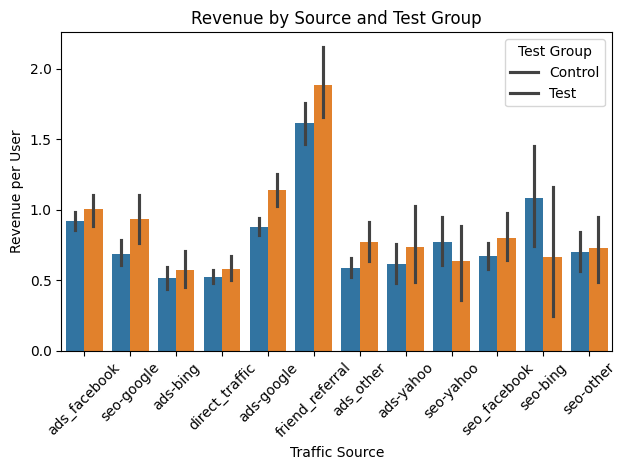

In [50]:
sns.barplot(x=merged_clean['source'], y=merged_clean['revenue'], hue=merged_clean['test'])
plt.xticks(rotation=45)
plt.title('Revenue by Source and Test Group')
plt.xlabel('Traffic Source')
plt.ylabel('Revenue per User')
plt.legend(title='Test Group', labels=['Control', 'Test'])
plt.tight_layout()
plt.show()

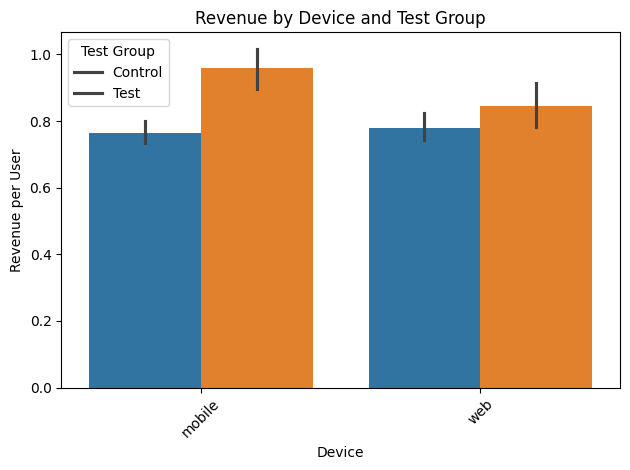

In [53]:
sns.barplot(x=merged_clean['device'], y=merged_clean['revenue'], hue=merged_clean['test'])
plt.xticks(rotation=45)
plt.title('Revenue by Device and Test Group')
plt.xlabel('Device')
plt.ylabel('Revenue per User')
plt.legend(title='Test Group', labels=['Control', 'Test'])
plt.tight_layout()
plt.show()

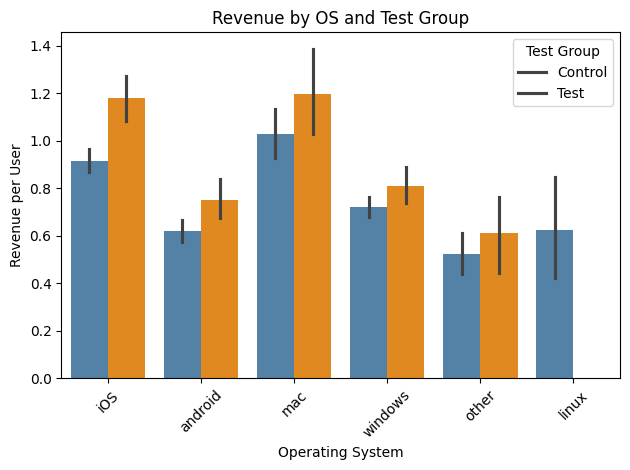

In [ ]:
sns.barplot(x=merged_clean['operative_system'], y=merged_clean['revenue'], hue=merged_clean['test'])
plt.xticks(rotation=45)
plt.title('Revenue by OS and Test Group')
plt.xlabel('Operating System')
plt.ylabel('Revenue per User')
plt.legend(title='Test Group', labels=['Control', 'Test'])
plt.tight_layout()
plt.show()

## Revenue by OS

- iOS, Android, Mac: $59 clearly generates higher RPU
- Windows: small lift, error bars overlap — not clearly different
- Other: noisy, error bars overlap — inconclusive
- Linux: no test group bar visible — too few users to analyze, exclude from recommendation

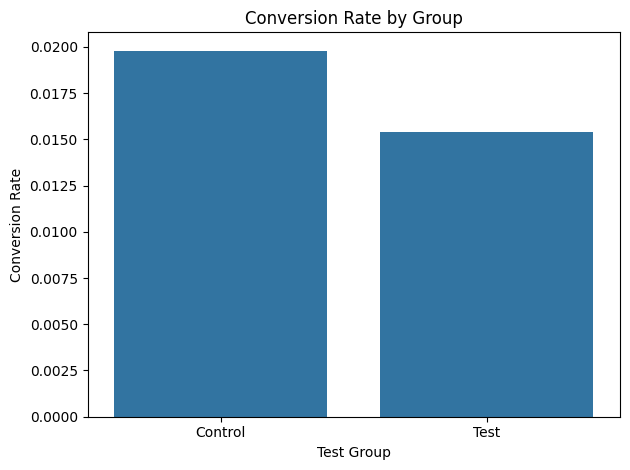

In [54]:
sns.barplot(x=conv_by_group.index, y=conv_by_group['conversion_rate'])
plt.xticks([0, 1], ['Control', 'Test'])
plt.title('Conversion Rate by Group')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

In [57]:
merged_clean.groupby(['operative_system', 'test']).size().unstack(fill_value=0)

test,0,1
operative_system,,
android,41977,23268
iOS,53707,29178
linux,1929,1701
mac,14277,7528
other,9188,4931
windows,55163,32447


In [58]:
merged_clean.groupby(['operative_system', 'test']).agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conv_rate=('converted', 'mean'),
    rpu=('revenue', 'mean')
).round(4)

users  conversions  conv_rate     rpu
operative_system test                                       
android          0     41977          670     0.0160  0.6225
                 1     23268          297     0.0128  0.7531
iOS              0     53707         1262     0.0235  0.9164
                 1     29178          584     0.0200  1.1809
linux            0      1929           31     0.0161  0.6267
                 1      1701            0     0.0000  0.0000
mac              0     14277          377     0.0264  1.0298
                 1      7528          153     0.0203  1.1991
other            0      9188          123     0.0134  0.5221
                 1      4931           51     0.0103  0.6102
windows          0     55163         1021     0.0185  0.7218
                 1     32447          445     0.0137  0.8092

## ⚠️ Anomaly: Linux Users at $59

Linux users in the test group ($59) had **0 conversions out of 1,701 users**, 
while Linux users at $39 converted normally.

The probability of zero conversions across 1,701 users, assuming a realistic 
conversion rate similar to other operating systems (~1-2%), is essentially 
zero

In [61]:
# RPU and conversion rate by source × test group
source_summary = merged_clean.groupby(['source', 'test']).agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conv_rate=('converted', 'mean'),
    rpu=('revenue', 'mean')
).round(4).reset_index()

print(source_summary)

             source  test  users  conversions  conv_rate     rpu
0          ads-bing     0  12663          168     0.0133  0.5174
1          ads-bing     1   7187           70     0.0097  0.5746
2        ads-google     0  32868          741     0.0225  0.8792
3        ads-google     1  18677          361     0.0193  1.1404
4         ads-yahoo     0   4160           66     0.0159  0.6188
5         ads-yahoo     1   2406           30     0.0125  0.7357
6      ads_facebook     0  29560          697     0.0236  0.9196
7      ads_facebook     1  16768          285     0.0170  1.0028
8         ads_other     0  16824          254     0.0151  0.5888
9         ads_other     1   9217          121     0.0131  0.7745
10   direct_traffic     0  33755          453     0.0134  0.5234
11   direct_traffic     1  18765          184     0.0098  0.5785
12  friend_referral     0  11415          472     0.0413  1.6126
13  friend_referral     1   6580          210     0.0319  1.8830
14         seo-bing     0

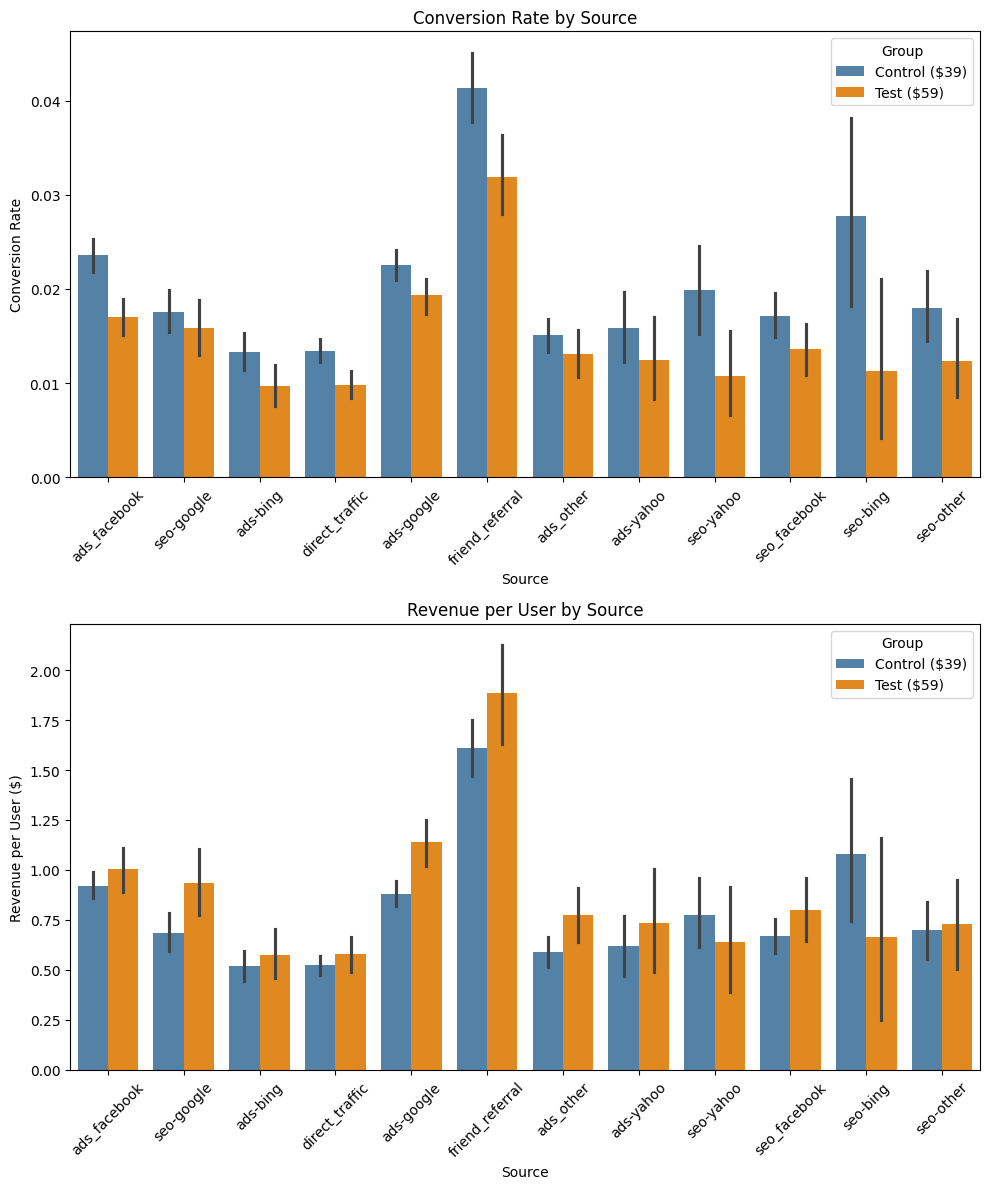

In [68]:


fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Conversion rate by source
sns.barplot(
    data=merged_clean,
    x='source', y='converted', hue='test',
    palette={0: 'steelblue', 1: 'darkorange'},
    ax=axes[0]
)
axes[0].set_title('Conversion Rate by Source')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xlabel('Source')
axes[0].tick_params(axis='x', rotation=45)
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=['Control ($39)', 'Test ($59)'], title='Group')

# RPU by source
sns.barplot(
    data=merged_clean,
    x='source', y='revenue', hue='test',
    palette={0: 'steelblue', 1: 'darkorange'},
    ax=axes[1]
)
axes[1].set_title('Revenue per User by Source')
axes[1].set_ylabel('Revenue per User ($)')
axes[1].set_xlabel('Source')
axes[1].tick_params(axis='x', rotation=45)
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=['Control ($39)', 'Test ($59)'], title='Group')

plt.tight_layout()
plt.show()

In [65]:
source_summary = merged_clean.groupby(['source', 'test']).agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conv_rate=('converted', 'mean'),
    rpu=('revenue', 'mean')
).round(4)

print(source_summary)

                      users  conversions  conv_rate     rpu
source          test                                       
ads-bing        0     12663          168     0.0133  0.5174
                1      7187           70     0.0097  0.5746
ads-google      0     32868          741     0.0225  0.8792
                1     18677          361     0.0193  1.1404
ads-yahoo       0      4160           66     0.0159  0.6188
                1      2406           30     0.0125  0.7357
ads_facebook    0     29560          697     0.0236  0.9196
                1     16768          285     0.0170  1.0028
ads_other       0     16824          254     0.0151  0.5888
                1      9217          121     0.0131  0.7745
direct_traffic  0     33755          453     0.0134  0.5234
                1     18765          184     0.0098  0.5785
friend_referral 0     11415          472     0.0413  1.6126
                1      6580          210     0.0319  1.8830
seo-bing        0      1154           32

## Segmentation: Source

**Clear $59 wins (real RPU lift, narrow error bars):**
- friend_referral — highest-value channel overall
- ads-google
- seo-google
- ads_other

**Inconclusive (bars overlap, RPU basically flat):**
- ads_facebook, ads-bing, direct_traffic — no harm from $59 but no clear gain

**Suspicious — possibly $39 wins:**
- seo-yahoo: $59 RPU lower than $39
- seo-bing: $39 looks better, but huge error bars (small sample, can't trust)

**Action:** For sources with insufficient data (seo-bing especially), 
recommend running a longer test. For seo-yahoo, investigate if it's a real
pattern or sample noise.

In [ ]:

def segment_analysis(df, segment_col, min_users=500):
    results = []
    for value in df[segment_col].unique():
        seg = df[df[segment_col] == value]
        control = seg[seg['test'] == 0]
        test = seg[seg['test'] == 1]
        
        if len(control) < min_users or len(test) < min_users:
            continue
        
        rpu_control, rpu_test = control['revenue'].mean(), test['revenue'].mean()
        perc_inc = (rpu_test - rpu_control) / rpu_control * 100
        
        conv = [control['converted'].sum(), test['converted'].sum()]
        n = [len(control), len(test)]
        _, p = proportions_ztest(conv, n)
        
        if p < 0.05:
            verdict = '$59 wins' if perc_inc > 0 else '$39 wins'
        else:
            verdict = 'Inconclusive'
        
        results.append({
            'segment': value,
            'control': len(control),
            'test': len(test),
            'rpu_control': round(rpu_control, 3),
            'rpu_test': round(rpu_test, 3),
            'diff%': round(perc_inc, 1),
            'p_value': round(p, 4),
            'verdict': verdict
        })
    
    return pd.DataFrame(results).sort_values('diff%', ascending=False)


# Run for each dimension
print("=== BY DEVICE ===")
print(segment_analysis(merged_clean, 'device'))

print("\n=== BY OS ===")
print(segment_analysis(merged_clean, 'operative_system'))

print("\n=== BY SOURCE ===")
print(segment_analysis(merged_clean, 'source'))

=== BY DEVICE ===
  segment  control   test  rpu_control  rpu_test  perc_inc_%  p_value  \
0  mobile   104805  57335        0.765     0.959        25.4      0.0   
1     web    71436  41718        0.780     0.846         8.4      0.0   

    verdict  
0  $59 wins  
1  $59 wins  

=== BY OS ===
   segment  control   test  rpu_control  rpu_test  perc_inc_%  p_value  \
0      iOS    53707  29178        0.916     1.181        28.9   0.0012   
1  android    41977  23268        0.622     0.753        21.0   0.0012   
4    other     9188   4931        0.522     0.610        16.9   0.1180   
2      mac    14277   7528        1.030     1.199        16.4   0.0056   
3  windows    55163  32447        0.722     0.809        12.1   0.0000   
5    linux     1929   1701        0.627     0.000      -100.0   0.0000   

        verdict  
0      $59 wins  
1      $59 wins  
4  Inconclusive  
2      $59 wins  
3      $59 wins  
5      $39 wins  

=== BY SOURCE ===
            segment  control   test  rpu_

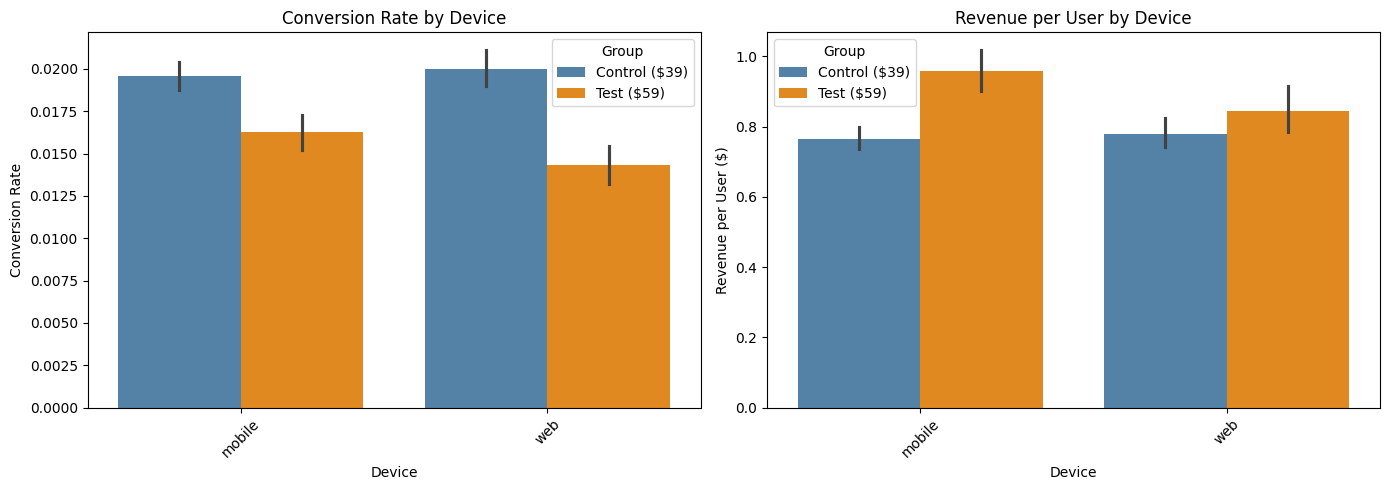

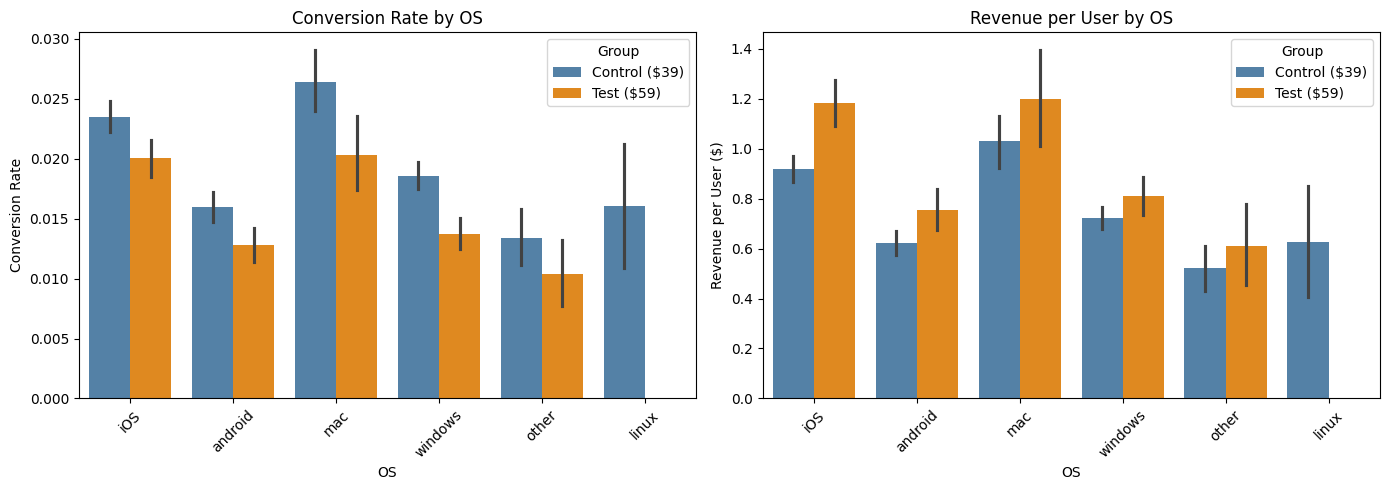

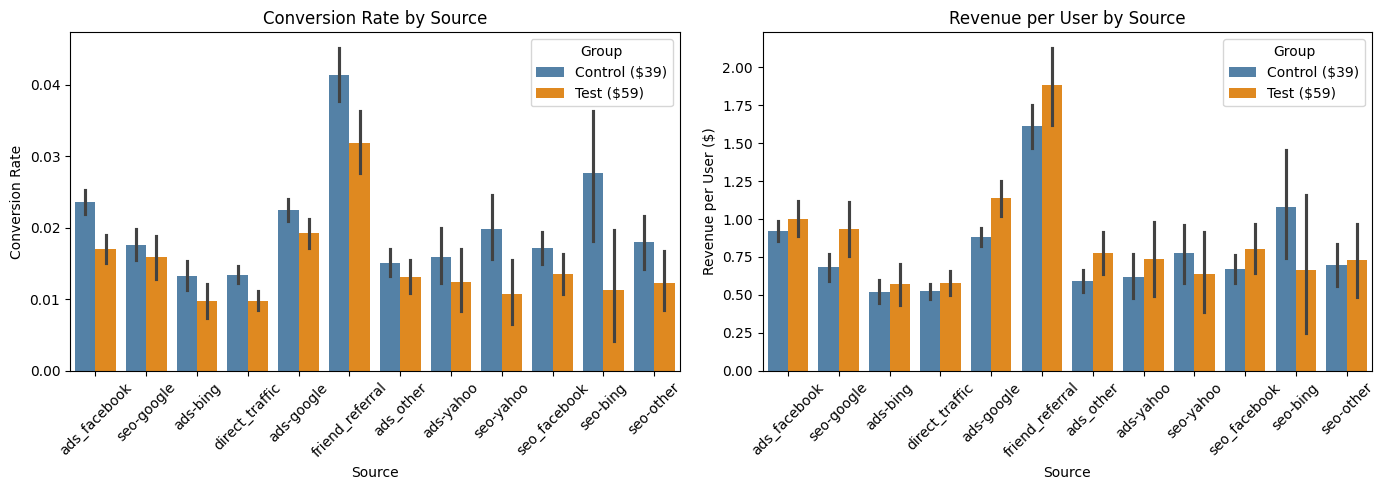

In [73]:


def plot_segment(df, segment_col, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Conversion rate
    sns.barplot(
        data=df, x=segment_col, y='converted', hue='test',
        palette={0: 'steelblue', 1: 'darkorange'},
        ax=axes[0], errorbar=('ci', 95)
    )
    axes[0].set_title(f'Conversion Rate by {title}')
    axes[0].set_ylabel('Conversion Rate')
    axes[0].set_xlabel(title)
    axes[0].tick_params(axis='x', rotation=45)
    handles, _ = axes[0].get_legend_handles_labels()
    axes[0].legend(handles=handles, labels=['Control ($39)', 'Test ($59)'], title='Group')
    
    # RPU
    sns.barplot(
        data=df, x=segment_col, y='revenue', hue='test',
        palette={0: 'steelblue', 1: 'darkorange'},
        ax=axes[1], errorbar=('ci', 95)
    )
    axes[1].set_title(f'Revenue per User by {title}')
    axes[1].set_ylabel('Revenue per User ($)')
    axes[1].set_xlabel(title)
    axes[1].tick_params(axis='x', rotation=45)
    handles, _ = axes[1].get_legend_handles_labels()
    axes[1].legend(handles=handles, labels=['Control ($39)', 'Test ($59)'], title='Group')
    
    plt.tight_layout()
    plt.show()


# Plot all three
plot_segment(merged_clean, 'device', 'Device')
plot_segment(merged_clean, 'operative_system', 'OS')
plot_segment(merged_clean, 'source', 'Source')